# 🌿 Évaluation croisée S1 ↔ S2 — *Ambrosia artemisiifolia* (YOLO11n-cls)

**Objectif.** Mesurer la capacité de généralisation **hors domaine** des deux modèles entraînés sur des sources d'images distinctes :

| Notation | Modèle | Données d'entraînement | Données de test croisé |
|----------|--------|------------------------|-------------------------|
| **S1 → D2** | `1er_yolo11n-cls.pt` | Données de recherche (D1) | Toutes les données (D2) |
| **S2 → D1** | `2e_yolo11n-cls.pt` | Toutes les données (D2) | Données de recherche (D1) |

**Validité méthodologique.** Seules les combinaisons croisées S1→D2 et S2→D1 sont évaluées. Les combinaisons S1→D1 et S2→D2 seraient contaminées par les données d'entraînement (*data leakage*) puisque `Photos_Positifs`/`Photos_Negatifs` d'un scénario contiennent déjà les splits train+val+test du modèle correspondant.

**Structure du notebook :**
1. Installation et configuration
2. Fonctions d'évaluation
3. Exécution des deux évaluations croisées
4. Tableau comparatif et métriques clés
5. Visualisations : barres, matrices de confusion, distributions
6. **Analyses croisées approfondies** *(nouvelles sections)*
   - Radar des métriques
   - Analyse des erreurs et profil d'échec
   - Biais de prédiction (score de confiance)
   - Synthèse interprétative
7. Sauvegarde et vérification

## 📦 Installation

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 77.8 MB/s eta 0:00:00


> Si c'est la **première installation** de la session, redémarre le runtime puis relance à partir de la cellule suivante.

## ⚙️ Configuration

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, json, warnings
from pathlib import Path
from datetime import datetime
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_auc_score, cohen_kappa_score,
)
from ultralytics import YOLO
from tqdm.auto import tqdm
import torch

warnings.filterwarnings('ignore')

# ── Chemins Google Drive ──
GDRIVE = '/content/drive/MyDrive'
S1_DIR = os.path.join(GDRIVE, '1er scénario_herbe_a_poux_yolo11ncls')
S2_DIR = os.path.join(GDRIVE, '2e scénario_herbe_a_poux_yolo11ncls')

S1_MODEL = os.path.join(S1_DIR, 'Modeles', '1er_yolo11n-cls.pt')
S2_MODEL = os.path.join(S2_DIR, 'Modeles', '2e_yolo11n-cls.pt')

D1_POS = os.path.join(S1_DIR, 'Photos_Positifs')
D1_NEG = os.path.join(S1_DIR, 'Photos_Negatifs')
D2_POS = os.path.join(S2_DIR, 'Photos_Positifs')
D2_NEG = os.path.join(S2_DIR, 'Photos_Negatifs')

OUT_DIR    = os.path.join(GDRIVE, 'Cross_Evaluation_S1_S2')
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE   = 224
BATCH_SIZE = 256
RUN_TAG    = datetime.now().strftime('%Y%m%d_%H%M%S')

# ── Palette graphique cohérente ──
PALETTE = {
    'S1→D2' : '#1565C0',   # bleu
    'S2→D1' : '#2E7D32',   # vert
    'correct': '#2E7D32',
    'error'  : '#C62828',
    'neutral': '#546E7A',
}

print('┌──────────────────────────────────────────────────────────┐')
print('│             Vérification des chemins                     │')
print('├──────────────────────────────────────────────────────────┤')
for label, p in [
    ('Modèle S1 ', S1_MODEL), ('Modèle S2 ', S2_MODEL),
    ('D1 Pos   ', D1_POS),   ('D1 Neg   ', D1_NEG),
    ('D2 Pos   ', D2_POS),   ('D2 Neg   ', D2_NEG),
]:
    status = '✓' if os.path.exists(p) else '✗ MANQUANT'
    print(f'│  {status}  {label} : {Path(p).name:<35}│')
print('└──────────────────────────────────────────────────────────┘')
print(f'Run    : {RUN_TAG}')
print(f'Sortie : {OUT_DIR}')

Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
┌──────────────────────────────────────────────────────────┐
│             Vérification des chemins                     │
├──────────────────────────────────────────────────────────┤
│  ✓  Modèle S1  : 1er_yolo11n-cls.pt                 │
│  ✓  Modèle S2  : 2e_yolo11n-cls.pt                  │
│  ✓  D1 Pos    : Photos_Positifs                    │
│  ✓  D1 Neg    : Photos_Negatifs                    │
│  ✓  D2 Pos    : Photos_Positifs                    │
│  ✓  D2 Neg    : Photos_Negatifs                    │
└──────────────────────────────────────────────────────────┘
Run    : 20260619_235133
Sortie : /content/drive/MyDrive/Cross_Evaluation_S1_S2


## 🧩 Fonction d'évaluation

L'évaluation prend en entrée les deux dossiers bruts (positifs + négatifs) et les mappe vers les labels du modèle. Les prédictions YOLO utilisent toujours les noms de classes d'**entraînement** (`ambrosia` / `non_ambrosia`), donc on mappe :

- `Photos_Positifs/` → index de `ambrosia` dans `model.names`
- `Photos_Negatifs/` → index de `non_ambrosia` dans `model.names`

Cela garantit que le mapping reste correct même si les classes du modèle sont dans un ordre différent.


In [3]:
IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def lister_images(dossier: str) -> list:
    """Liste récursive et triée des images dans un dossier."""
    if not os.path.exists(dossier):
        return []
    return sorted([
        str(p) for p in Path(dossier).rglob('*')
        if p.suffix.lower() in IMG_EXT
    ])


def wilson_ci(p: float, n: int, z: float = 1.96) -> tuple:
    """Intervalle de confiance de Wilson (1927) à 95 %."""
    if n == 0:
        return (0.0, 0.0)
    denom  = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    marge  = (z / denom) * math.sqrt(p*(1-p)/n + z**2/(4*n**2))
    return (max(0.0, centre - marge), min(1.0, centre + marge))


# ── Largeur fixe pour toutes les barres ──
_BAR_W = 110
_FMT_COPY = (
    '{desc} |{bar}| '
    '{n_fmt:>6}/{total_fmt} imgs '
    '[{elapsed} < {remaining}  {rate_fmt}]'
)
_FMT_INF = (
    '{desc} |{bar}| '
    '{n_fmt:>6}/{total_fmt} imgs '
    '[{elapsed} < {remaining}  {rate_fmt}]  '
    'batch {postfix}'
)


def _sep(titre: str = '', car: str = '─', w: int = _BAR_W) -> None:
    """Imprime une ligne de séparation avec un titre optionnel centré."""
    if titre:
        pad   = max(0, w - len(titre) - 2)
        left  = pad // 2
        right = pad - left
        print(car * left + ' ' + titre + ' ' + car * right)
    else:
        print(car * w)


def evaluer(model_path: str, pos_dir: str, neg_dir: str, nom: str) -> dict:
    import tempfile, shutil, time as _time

    # ── En-tête ──
    print()
    _sep(nom, '═')
    print(f'  Modèle  : {Path(model_path).name}')
    print(f'  Pos     : {Path(pos_dir).name}')
    print(f'  Neg     : {Path(neg_dir).name}')

    # ── Chargement modèle ──
    print()
    _sep('Chargement du modèle', '·')
    model = YOLO(model_path)
    class_names = [model.names[i] for i in sorted(model.names.keys())]
    print(f'  Classes : {class_names}')

    idx_ambr = next(
        (i for i, n in enumerate(class_names) if n.lower().startswith('ambrosia')), None)
    idx_neg  = next(
        (i for i, n in enumerate(class_names)
         if 'non' in n.lower() or 'neg' in n.lower()), None)
    if idx_ambr is None or idx_neg is None:
        raise ValueError(f'Mapping classes impossible : {class_names}')

    # ── Inventaire images ──
    print()
    _sep('Inventaire des images', '·')
    pos_imgs = lister_images(pos_dir)
    neg_imgs = lister_images(neg_dir)
    paths    = pos_imgs + neg_imgs
    y_true   = np.array([idx_ambr] * len(pos_imgs) + [idx_neg] * len(neg_imgs))
    print(f'  ambrosia     (Pos) : {len(pos_imgs):>6} images')
    print(f'  non_ambrosia (Neg) : {len(neg_imgs):>6} images')
    print(f'  Total              : {len(paths):>6} images')

    if len(paths) == 0:
        raise ValueError(f'Aucune image dans {pos_dir} ou {neg_dir}')

    # ── Phase 1 : Copie Drive → disque local ──
    print()
    _sep('Phase 1 / 2  —  Copie Drive → disque local', '·')
    local_dir   = tempfile.mkdtemp(prefix='cross_eval_')
    local_paths = []
    t0_copy     = _time.time()

    pbar_copy = tqdm(
        paths,
        desc      = '  📂 Copie',
        unit      = 'img',
        ncols     = _BAR_W,
        colour    = 'cyan',
        bar_format= _FMT_COPY,
        miniters  = 50,      # rafraîchit toutes les 50 imgs → fluide sans lag
        smoothing = 0.05,    # ETA stable
    )
    for i, src_path in enumerate(pbar_copy):
        ext = Path(src_path).suffix.lower()
        dst = os.path.join(local_dir, f'{i:06d}{ext}')
        shutil.copy(src_path, dst)
        local_paths.append(dst)
    pbar_copy.close()

    dt_copy = _time.time() - t0_copy
    print(f'  ✓ Copie terminée en {dt_copy:.1f}s '
          f'({len(local_paths)/dt_copy:.0f} imgs/s)')

    # ── Phase 2 : Inférence batchée ──
    print()
    _sep('Phase 2 / 2  —  Inférence YOLO (batch)', '·')
    n_classes = len(class_names)
    y_pred    = np.zeros(len(paths), dtype=int)
    y_scores  = np.zeros((len(paths), n_classes), dtype=float)

    device   = 0 if torch.cuda.is_available() else 'cpu'
    use_half = torch.cuda.is_available()
    n_batches = math.ceil(len(local_paths) / BATCH_SIZE)
    t0_inf    = _time.time()

    pbar_inf = tqdm(
        total     = len(local_paths),
        desc      = '  🔍 Inférence',
        unit      = 'img',
        ncols     = _BAR_W,
        colour    = 'green',
        bar_format= (
            '{desc} |{bar}| '
            '{n_fmt:>6}/{total_fmt} imgs '
            '[{elapsed} < {remaining}  {rate_fmt}]'
        ),
        smoothing = 0.05,
    )
    with torch.inference_mode():
        for b_idx, start in enumerate(range(0, len(local_paths), BATCH_SIZE)):
            end     = min(start + BATCH_SIZE, len(local_paths))
            results = model.predict(
                local_paths[start:end],
                imgsz   = IMG_SIZE,
                verbose = False,
                device  = device,
                half    = use_half,
            )
            for k, r in enumerate(results):
                probs = r.probs.data.cpu().numpy()
                y_scores[start + k] = probs
                y_pred[start + k]   = int(probs.argmax())
            pbar_inf.update(end - start)
            # Postfix batch courant
            pbar_inf.set_postfix_str(
                f'{b_idx+1}/{n_batches}', refresh=True)
    pbar_inf.close()

    dt_inf = _time.time() - t0_inf
    print(f'  ✓ Inférence terminée en {dt_inf:.1f}s '
          f'({len(local_paths)/dt_inf:.0f} imgs/s)')

    shutil.rmtree(local_dir, ignore_errors=True)

    # ── Métriques ──
    print()
    _sep('Métriques', '·')
    acc   = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0)
    prec_cls, rec_cls, f1_cls, sup_cls = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0)
    try:
        auc = roc_auc_score(
            (y_true == idx_ambr).astype(int), y_scores[:, idx_ambr])
    except Exception as e:
        print(f'  ROC-AUC indisponible : {e}')
        auc = None
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))

    wilson_per_class = {}
    for i, cls in enumerate(class_names):
        n_cls = int(sup_cls[i]) if i < len(sup_cls) else 0
        p_cls = float(rec_cls[i]) if i < len(rec_cls) else 0.0
        wilson_per_class[cls] = wilson_ci(p_cls, n_cls)

    correct_mask   = (y_pred == y_true)
    conf_correct   = y_scores[correct_mask,  y_pred[correct_mask]].tolist()
    conf_incorrect = y_scores[~correct_mask, y_pred[~correct_mask]].tolist()

    lo_acc, hi_acc = wilson_ci(float(acc), len(paths))
    print(f'  Accuracy  : {acc*100:6.2f}%  '
          f'IC Wilson 95% [{lo_acc*100:.2f}%–{hi_acc*100:.2f}%]')
    print(f'  F1-Macro  : {f1:.4f}')
    print(f'  Précision : {prec:.4f}')
    print(f'  Rappel    : {rec:.4f}')
    print(f'  Kappa     : {kappa:.4f}')
    if auc is not None:
        print(f'  ROC-AUC   : {auc:.4f}')
    print()
    print(classification_report(
        y_true, y_pred,
        target_names=class_names, digits=4, zero_division=0))
    _sep('', '═')

    return {
        'nom'             : nom,
        'n_images'        : len(paths),
        'n_pos'           : len(pos_imgs),
        'n_neg'           : len(neg_imgs),
        'class_names'     : class_names,
        'idx_ambr'        : idx_ambr,
        'accuracy'        : float(acc),
        'f1_macro'        : float(f1),
        'precision'       : float(prec),
        'recall'          : float(rec),
        'kappa'           : float(kappa),
        'auc'             : float(auc) if auc is not None else None,
        'confusion'       : cm.tolist(),
        'prec_cls'        : prec_cls.tolist(),
        'rec_cls'         : rec_cls.tolist(),
        'f1_cls'          : f1_cls.tolist(),
        'sup_cls'         : sup_cls.tolist(),
        'wilson_per_class': wilson_per_class,
        'wilson_acc'      : wilson_ci(float(acc), len(paths)),
        'conf_correct'    : conf_correct,
        'conf_incorrect'  : conf_incorrect,
        'y_true'          : y_true.tolist(),
        'y_pred'          : y_pred.tolist(),
        'y_scores'        : y_scores.tolist(),
    }


## 🧪 Exécution des cross-évaluations

In [4]:
import time

EVALS = [
    dict(
        model_path = S1_MODEL,
        pos_dir    = D2_POS,
        neg_dir    = D2_NEG,
        nom        = 'S1 → D2  (Données de recherche → Toutes les données)',
    ),
    dict(
        model_path = S2_MODEL,
        pos_dir    = D1_POS,
        neg_dir    = D1_NEG,
        nom        = 'S2 → D1  (Toutes les données → Données de recherche)',
    ),
]

resultats_bruts = []
t0_global = time.time()

for i_eval, cfg in enumerate(EVALS, 1):
    # ── Bandeau de démarrage pour chaque évaluation ──
    print()
    sep = '═' * 110
    print(sep)
    print(f"  🔄  Évaluation {i_eval}/{len(EVALS)} : {cfg['nom']}")
    print(sep)

    t0  = time.time()
    res = evaluer(**cfg)
    res['elapsed_s'] = round(time.time() - t0, 1)
    resultats_bruts.append(res)

    # ── Mini-résumé immédiat après chaque évaluation ──
    lo, hi = res['wilson_acc']
    print(f"  ✅  Terminé en {res['elapsed_s']}s  "
          f"— Accuracy : {res['accuracy']*100:.2f}%  "
          f"IC Wilson [{lo*100:.2f}%–{hi*100:.2f}%]  "
          f"F1 : {res['f1_macro']:.4f}  Kappa : {res['kappa']:.4f}")

t_total = time.time() - t0_global

# Décompacter pour compatibilité avec le reste du notebook
res_M1_D2, res_M2_D1 = resultats_bruts

# ── Récapitulatif final ──
print()
print('┌─────────────────────────────────────────────────────────────────┐')
print('│  ✅  Cross-évaluations terminées                                │')
print('├─────────────────────────────────────────────────────────────────┤')
for res in resultats_bruts:
    lo, hi = res['wilson_acc']
    print(f"│  {res['nom']:<63}│")
    print(f"│    Accuracy : {res['accuracy']*100:6.2f}%  "
          f"IC Wilson 95% [{lo*100:.2f}%–{hi*100:.2f}%]          │")
    print(f"│    F1-Macro : {res['f1_macro']:.4f}   "
          f"Kappa : {res['kappa']:.4f}   "
          f"Temps : {res['elapsed_s']}s                 │")
    print('├─────────────────────────────────────────────────────────────────┤')
print(f'│  ⏱  Durée totale : {t_total:.1f}s                                          │')
print('└─────────────────────────────────────────────────────────────────┘')



══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  🔄  Évaluation 1/2 : S1 → D2  (Données de recherche → Toutes les données)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════

════════════════════════════ S1 → D2  (Données de recherche → Toutes les données) ════════════════════════════
  Modèle  : 1er_yolo11n-cls.pt
  Pos     : Photos_Positifs
  Neg     : Photos_Negatifs

············································ Chargement du modèle ············································
  Classes : ['ambrosia', 'non_ambrosia']

··········································· Inventaire des images ············································
  ambrosia     (Pos) :   5454 images
  non_ambrosia (Neg) :   5458 images
  Total              :  10912 images

································· Phase 1 / 2  —  Copie Drive → disque local ·································


  📂 Copie |                                                           |      0/10912 imgs [00:00 < ?  ?img/s]

  ✓ Copie terminée en 5280.0s (2 imgs/s)

··································· Phase 2 / 2  —  Inférence YOLO (batch) ···································


  🔍 Inférence |                                                       |      0/10912 imgs [00:00 < ?  ?img/s]

  ✓ Inférence terminée en 932.7s (12 imgs/s)

················································· Métriques ··················································
  Accuracy  :  88.27%  IC Wilson 95% [87.65%–88.86%]
  F1-Macro  : 0.8827
  Précision : 0.8827
  Rappel    : 0.8827
  Kappa     : 0.7654
  ROC-AUC   : 0.9504

              precision    recall  f1-score   support

    ambrosia     0.8848    0.8799    0.8823      5454
non_ambrosia     0.8806    0.8855    0.8831      5458

    accuracy                         0.8827     10912
   macro avg     0.8827    0.8827    0.8827     10912
weighted avg     0.8827    0.8827    0.8827     10912

══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  ✅  Terminé en 6233.5s  — Accuracy : 88.27%  IC Wilson [87.65%–88.86%]  F1 : 0.8827  Kappa : 0.7654

══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  🔄  Évaluation 2/2 : S2 → D1  (T

  📂 Copie |                                                            |      0/1209 imgs [00:00 < ?  ?img/s]

  ✓ Copie terminée en 523.9s (2 imgs/s)

··································· Phase 2 / 2  —  Inférence YOLO (batch) ···································


  🔍 Inférence |                                                        |      0/1209 imgs [00:00 < ?  ?img/s]

  ✓ Inférence terminée en 75.8s (16 imgs/s)

················································· Métriques ··················································
  Accuracy  :  95.78%  IC Wilson 95% [94.50%–96.78%]
  F1-Macro  : 0.9578
  Précision : 0.9590
  Rappel    : 0.9578
  Kappa     : 0.9156
  ROC-AUC   : 0.9924

              precision    recall  f1-score   support

    ambrosia     0.9355    0.9835    0.9589       605
non_ambrosia     0.9825    0.9321    0.9567       604

    accuracy                         0.9578      1209
   macro avg     0.9590    0.9578    0.9578      1209
weighted avg     0.9590    0.9578    0.9578      1209

══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  ✅  Terminé en 601.3s  — Accuracy : 95.78%  IC Wilson [94.50%–96.78%]  F1 : 0.9578  Kappa : 0.9156

┌─────────────────────────────────────────────────────────────────┐
│  ✅  Cross-évaluations terminées                                │
├──────────

## 📊 Tableau comparatif

In [5]:
resultats = [res_M1_D2, res_M2_D1]

# ── Tableau principal enrichi ──
rows = []
for r in resultats:
    lo, hi = r['wilson_acc']
    rows.append({
        'Évaluation'            : r['nom'],
        'N images'              : r['n_images'],
        'N Pos / Neg'           : f"{r['n_pos']} / {r['n_neg']}",
        'Accuracy'              : f"{r['accuracy']*100:.2f}%",
        'IC Wilson 95%'         : f"[{lo*100:.2f}%–{hi*100:.2f}%]",
        'F1-Macro'              : f"{r['f1_macro']:.4f}",
        'Précision'             : f"{r['precision']:.4f}",
        'Rappel'                : f"{r['recall']:.4f}",
        'Kappa'                 : f"{r['kappa']:.4f}",
        'ROC-AUC'               : f"{r['auc']:.4f}" if r['auc'] else 'n/a',
    })

df_main = pd.DataFrame(rows)
print('═'*90)
print('  TABLEAU COMPARATIF — CROSS-ÉVALUATION S1 ↔ S2')
print('═'*90)
print(df_main.to_string(index=False))
print()

# ── Tableau par classe ──
print('═'*90)
print('  MÉTRIQUES PAR CLASSE')
print('═'*90)
rows_cls = []
for r in resultats:
    for i, cls in enumerate(r['class_names']):
        lo_c, hi_c = r['wilson_per_class'].get(cls, (0, 0))
        rows_cls.append({
            'Évaluation' : r['nom'],
            'Classe'     : cls,
            'Support'    : int(r['sup_cls'][i]) if i < len(r['sup_cls']) else '',
            'Précision'  : f"{r['prec_cls'][i]:.4f}" if i < len(r['prec_cls']) else '',
            'Rappel'     : f"{r['rec_cls'][i]:.4f}"  if i < len(r['rec_cls'])  else '',
            'F1'         : f"{r['f1_cls'][i]:.4f}"   if i < len(r['f1_cls'])   else '',
            'IC Wilson (Rappel) 95%': f"[{lo_c:.4f}–{hi_c:.4f}]",
        })
df_cls = pd.DataFrame(rows_cls)
print(df_cls.to_string(index=False))
print()

# ── Export CSV ──
df_main.to_csv(os.path.join(OUT_DIR, f'resume_cross_eval_{RUN_TAG}.csv'), index=False)
df_cls.to_csv(os.path.join(OUT_DIR,  f'metriques_par_classe_{RUN_TAG}.csv'), index=False)
print(f'✓ CSV sauvegardés dans {OUT_DIR}')

══════════════════════════════════════════════════════════════════════════════════════════
  TABLEAU COMPARATIF — CROSS-ÉVALUATION S1 ↔ S2
══════════════════════════════════════════════════════════════════════════════════════════
                                          Évaluation  N images N Pos / Neg Accuracy   IC Wilson 95% F1-Macro Précision Rappel  Kappa ROC-AUC
S1 → D2  (Données de recherche → Toutes les données)     10912 5454 / 5458   88.27% [87.65%–88.86%]   0.8827    0.8827 0.8827 0.7654  0.9504
S2 → D1  (Toutes les données → Données de recherche)      1209   605 / 604   95.78% [94.50%–96.78%]   0.9578    0.9590 0.9578 0.9156  0.9924

══════════════════════════════════════════════════════════════════════════════════════════
  MÉTRIQUES PAR CLASSE
══════════════════════════════════════════════════════════════════════════════════════════
                                          Évaluation       Classe  Support Précision Rappel     F1 IC Wilson (Rappel) 95%
S1 → D2  (Données d

## 📈 Visualisations

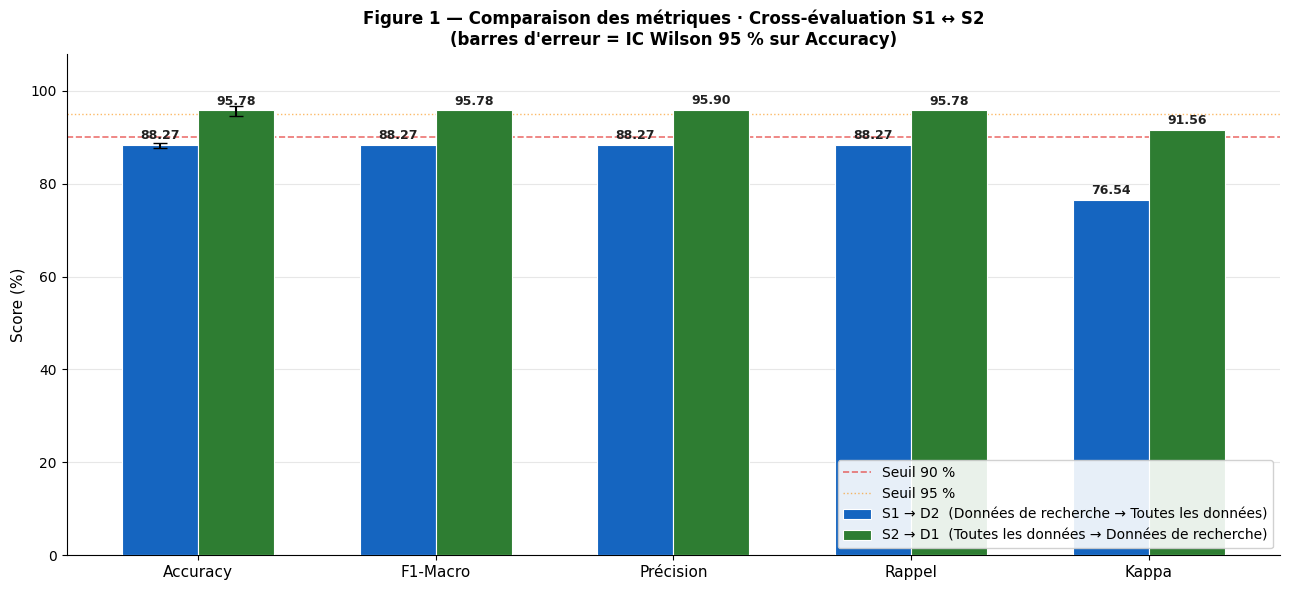

✓ Figure 1 sauvegardée


In [8]:
# ── Figure 1 : Barres comparatives multi-métriques avec IC Wilson ──
metriques = ['accuracy', 'f1_macro', 'precision', 'recall', 'kappa']
labels_metr = ['Accuracy', 'F1-Macro', 'Précision', 'Rappel', 'Kappa']
couleurs = [PALETTE['S1→D2'], PALETTE['S2→D1']]

fig, ax = plt.subplots(figsize=(13, 6))
n_m = len(metriques)
x   = np.arange(n_m)
w   = 0.32

for j, (res, col) in enumerate(zip(resultats, couleurs)):
    vals = [res[m]*100 for m in metriques]
    bars = ax.bar(x + (j - 0.5)*w, vals, w,
                  label=res['nom'], color=col, edgecolor='white', linewidth=0.8, zorder=3)
    # IC Wilson sur Accuracy uniquement (indiqué par whiskers)
    lo, hi = res['wilson_acc']
    ax.errorbar(
        x[0] + (j - 0.5)*w, res['accuracy']*100,
        yerr=[[res['accuracy']*100 - lo*100], [hi*100 - res['accuracy']*100]],
        fmt='none', color='black', capsize=5, linewidth=1.5, zorder=4
    )
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.6,
                f'{v:.2f}', ha='center', va='bottom',
                fontweight='bold', fontsize=9, color='#212121')

ax.axhline(90, color='#E53935', linestyle='--', linewidth=1.2, alpha=0.7, label='Seuil 90 %', zorder=2)
ax.axhline(95, color='#FB8C00', linestyle=':', linewidth=1.0, alpha=0.6, label='Seuil 95 %', zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(labels_metr, fontsize=11)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_ylim(0, 108)
ax.set_title('Figure 1 — Comparaison des métriques · Cross-évaluation S1 ↔ S2\n'
             "(barres d'erreur = IC Wilson 95 % sur Accuracy)", fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'fig1_barres_{RUN_TAG}.png'), dpi=150)
plt.show()
print('✓ Figure 1 sauvegardée')

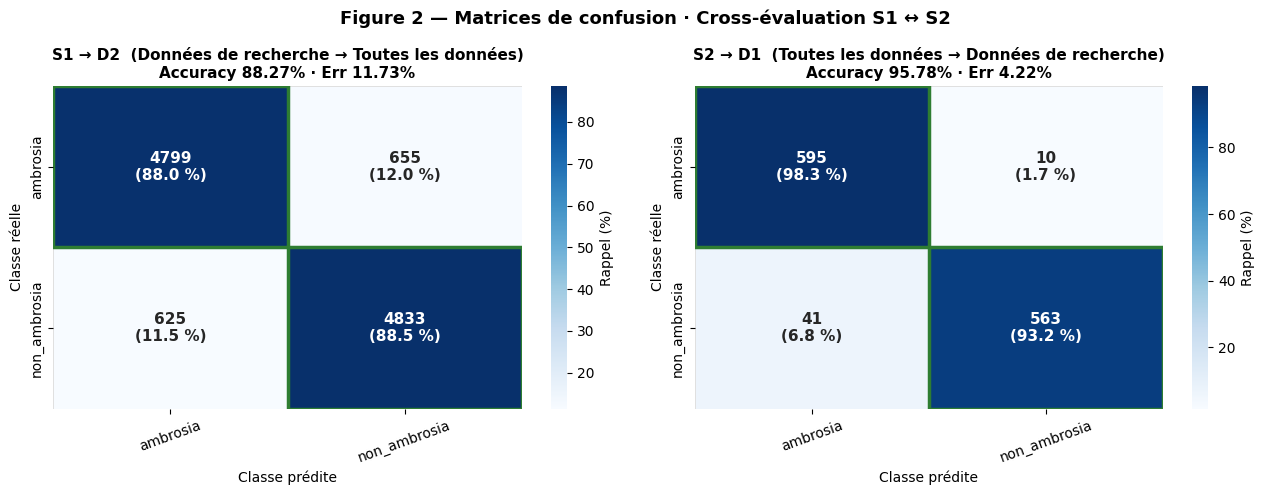

✓ Figure 2 sauvegardée


In [9]:
# ── Figure 2 : Matrices de confusion (absolues + %) avec taux d'erreur ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, res in zip(axes, resultats):
    cm   = np.array(res['confusion'])
    totR = cm.sum(axis=1, keepdims=True)
    cm_pct = np.where(totR > 0, cm / totR * 100, 0.0)

    annot = [[f'{cm[i,j]}\n({cm_pct[i,j]:.1f} %)'
              for j in range(cm.shape[1])] for i in range(cm.shape[0])]

    mask_diag = np.eye(cm.shape[0], dtype=bool)
    sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
                xticklabels=res['class_names'], yticklabels=res['class_names'],
                cbar_kws={'label': 'Rappel (%)'}, ax=ax,
                annot_kws={'size': 11, 'weight': 'bold'},
                linewidths=0.5, linecolor='#E0E0E0')

    # Encadrer les cases correctes en vert
    for i in range(cm.shape[0]):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='#2E7D32', lw=2.5))

    # Taux d'erreur global dans le titre
    err = (1 - res['accuracy']) * 100
    ax.set_title(f"{res['nom']}\nAccuracy {res['accuracy']*100:.2f}% · Err {err:.2f}%",
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Classe prédite', fontsize=10)
    ax.set_ylabel('Classe réelle', fontsize=10)
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('Figure 2 — Matrices de confusion · Cross-évaluation S1 ↔ S2',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'fig2_confusion_{RUN_TAG}.png'), dpi=150)
plt.show()
print('✓ Figure 2 sauvegardée')

## 📊 Distribution des prédictions correctes / incorrectes par classe

Pour chaque cross-évaluation et chaque classe (`ambrosia`, `non_ambrosia`), on compte combien d'images sont correctement classifiées vs mal classifiées. C'est une lecture complémentaire des matrices de confusion : les barres empilées mettent en évidence si un modèle échoue surtout sur la classe positive ou négative.


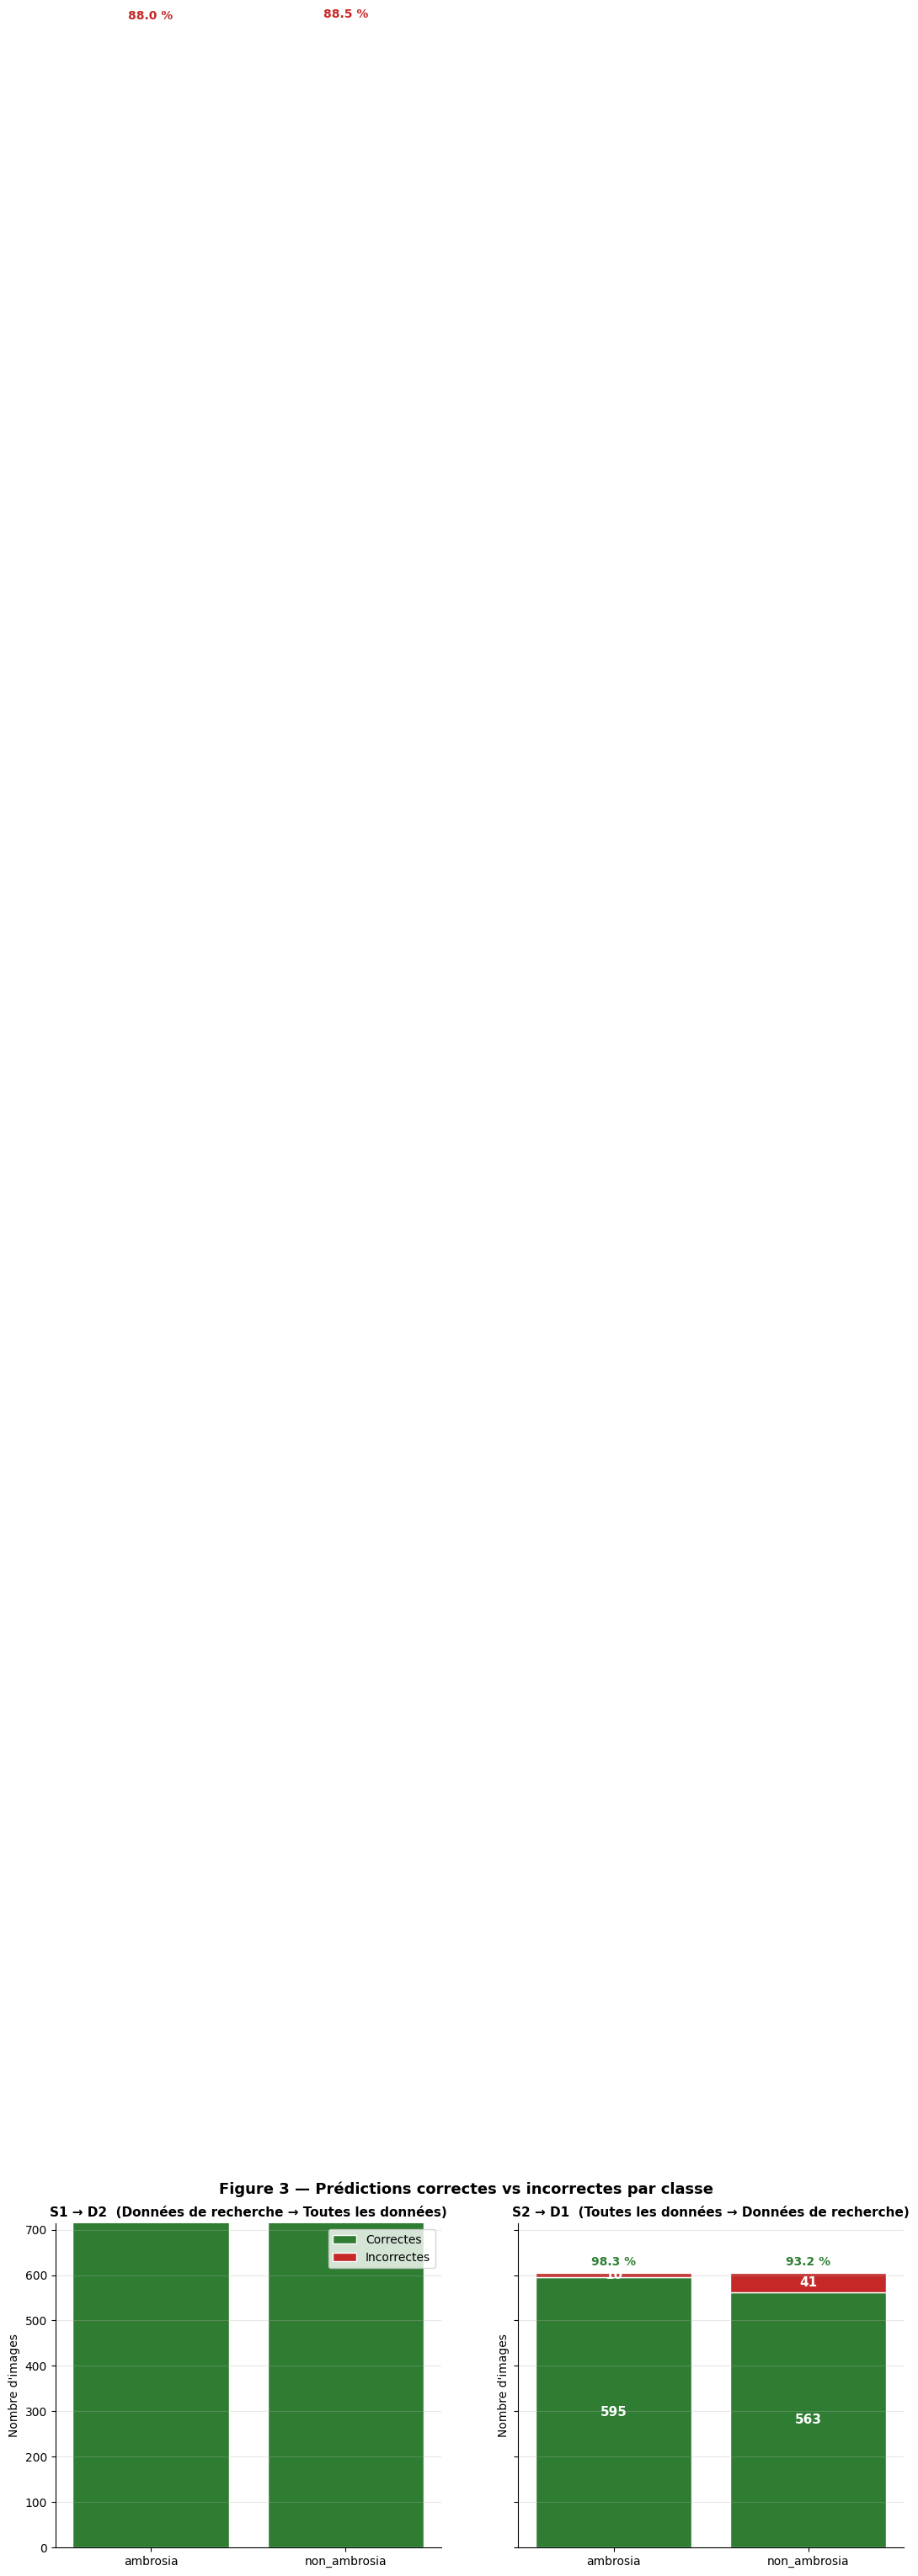


  S1 → D2  (Données de recherche → Toutes les données)
    ambrosia        :  4799 /  5454  ( 88.0 %)  IC Wilson 95% [0.8710–0.8883]
    non_ambrosia    :  4833 /  5458  ( 88.5 %)  IC Wilson 95% [0.8768–0.8937]

  S2 → D1  (Toutes les données → Données de recherche)
    ambrosia        :   595 /   605  ( 98.3 %)  IC Wilson 95% [0.9698–0.9910]
    non_ambrosia    :   563 /   604  ( 93.2 %)  IC Wilson 95% [0.9092–0.9496]



In [10]:
# ── Figure 3 : Distribution correct / incorrect par classe ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, res in zip(axes, resultats):
    cm          = np.array(res['confusion'])
    class_names = res['class_names']
    corrects    = np.diag(cm)
    incorrects  = cm.sum(axis=1) - corrects
    totals      = corrects + incorrects

    x = np.arange(len(class_names))
    b_ok = ax.bar(x, corrects,   color=PALETTE['correct'], edgecolor='white', label='Correctes')
    b_ko = ax.bar(x, incorrects, bottom=corrects, color=PALETTE['error'], edgecolor='white', label='Incorrectes')

    for i, (ok, ko, tot) in enumerate(zip(corrects, incorrects, totals)):
        pct = (ok / tot * 100) if tot > 0 else 0
        if ok > 0:
            ax.text(i, ok / 2, f'{int(ok)}', ha='center', va='center',
                    color='white', fontweight='bold', fontsize=11)
        if ko > 0:
            ax.text(i, ok + ko / 2, f'{int(ko)}', ha='center', va='center',
                    color='white', fontweight='bold', fontsize=11)
        color_pct = PALETTE['correct'] if pct >= 90 else PALETTE['error']
        ax.text(i, tot + max(totals) * 0.02, f'{pct:.1f} %',
                ha='center', va='bottom', fontweight='bold', fontsize=10, color=color_pct)

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, fontsize=10)
    ax.set_title(res['nom'], fontweight='bold', fontsize=11)
    ax.set_ylabel('Nombre d\'images')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(totals) * 1.18)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].legend(loc='upper right', fontsize=10)
fig.suptitle('Figure 3 — Prédictions correctes vs incorrectes par classe',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'fig3_distribution_{RUN_TAG}.png'), dpi=150)
plt.show()

print()
for res in resultats:
    cm = np.array(res['confusion'])
    print(f'  {res["nom"]}')
    for i, cls in enumerate(res['class_names']):
        ok  = int(np.diag(cm)[i])
        tot = int(cm.sum(axis=1)[i])
        ko  = tot - ok
        pct = ok / tot * 100 if tot > 0 else 0
        lo, hi = res['wilson_per_class'].get(cls, (0, 0))
        print(f'    {cls:<15} : {ok:5d} / {tot:5d}  '
              f'({pct:5.1f} %)  IC Wilson 95% [{lo:.4f}–{hi:.4f}]')
    print()

## 📡 Analyse croisée — Radar des métriques

Le graphique radar permet de visualiser simultanément cinq métriques pour chaque évaluation croisée : Accuracy, F1-Macro, Précision, Rappel et Kappa. Une surface plus large indique une meilleure généralisation hors domaine. L'asymétrie entre les deux polygones révèle dans quelle dimension un modèle est le plus pénalisé lors du transfert vers un domaine non vu.

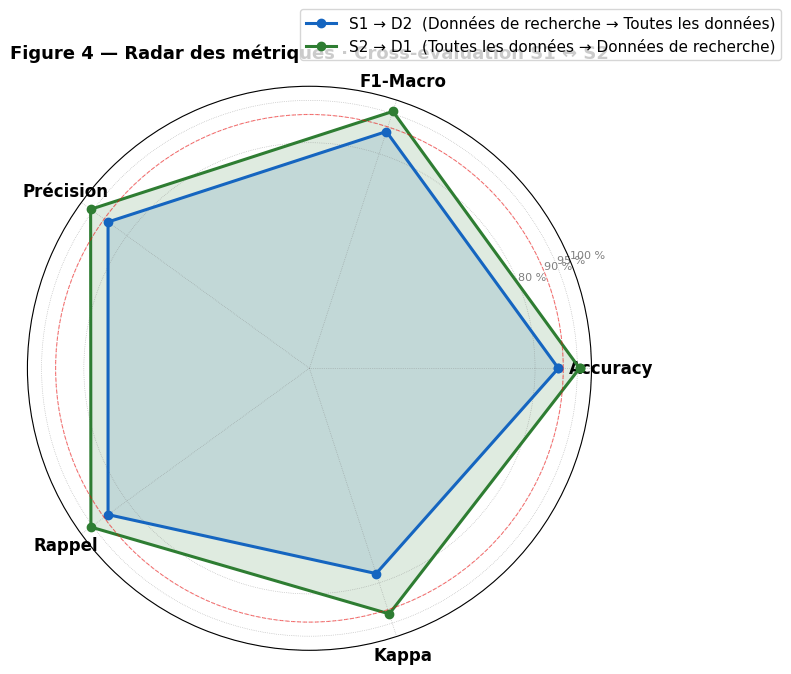

✓ Figure 4 sauvegardée


In [11]:
# ── Figure 4 : Radar des métriques ──
cats   = ['Accuracy', 'F1-Macro', 'Précision', 'Rappel', 'Kappa']
keys   = ['accuracy', 'f1_macro', 'precision', 'recall', 'kappa']
N      = len(cats)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # fermer le polygone

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors_radar = [PALETTE['S1→D2'], PALETTE['S2→D1']]
for res, col in zip(resultats, colors_radar):
    vals = [res[k] for k in keys] + [res[keys[0]]]
    ax.plot(angles, vals, 'o-', linewidth=2.2, color=col, label=res['nom'])
    ax.fill(angles, vals, alpha=0.15, color=col)

# Grille à 80 / 90 / 95 / 100 %
ax.set_ylim(0, 1)
ax.set_yticks([0.80, 0.90, 0.95, 1.00])
ax.set_yticklabels(['80 %', '90 %', '95 %', '100 %'], fontsize=8, color='grey')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=12, fontweight='bold')
ax.axhline(0.90, color='red', linestyle='--', linewidth=0.8, alpha=0.5)

ax.set_title('Figure 4 — Radar des métriques · Cross-évaluation S1 ↔ S2',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.grid(color='grey', linestyle=':', linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'fig4_radar_{RUN_TAG}.png'), dpi=150)
plt.show()
print('✓ Figure 4 sauvegardée')

## 🔬 Analyse des erreurs — Profil d'échec par classe

Cette section examine où chaque modèle échoue. Pour chaque évaluation croisée, on distingue :
- **Faux Négatifs (FN)** : images *ambrosia* classées comme *non_ambrosia* — sous-détection de la plante cible.
- **Faux Positifs (FP)** : images *non_ambrosia* classées comme *ambrosia* — fausse alarme.

Le taux de FN est particulièrement critique dans le contexte de surveillance phytosanitaire : une herbe à poux non détectée représente un risque direct pour la santé publique.

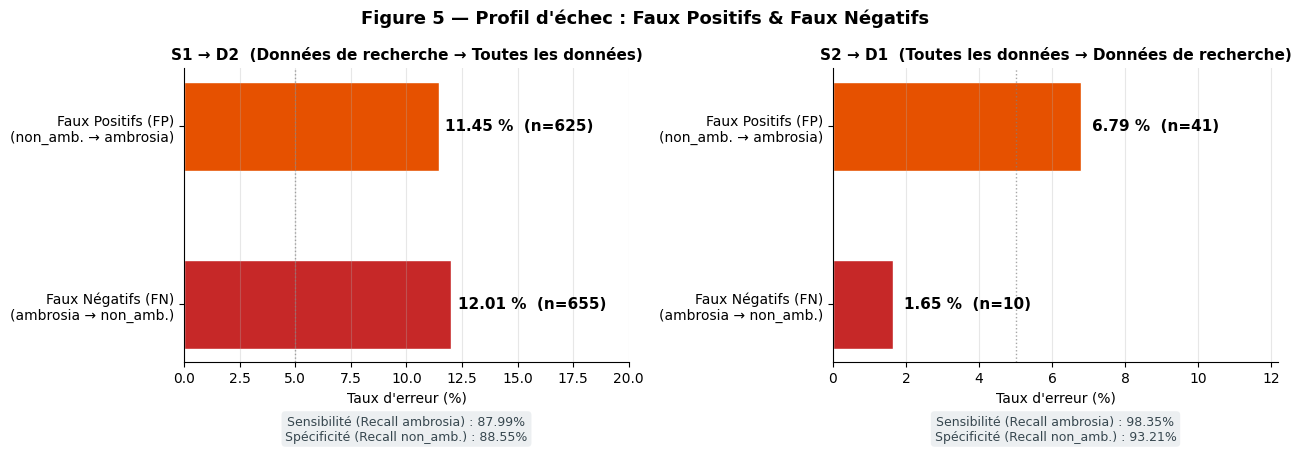

✓ Figure 5 sauvegardée


In [12]:
# ── Figure 5 : Profil d'échec FP / FN ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, res in zip(axes, resultats):
    cm          = np.array(res['confusion'])
    class_names = res['class_names']
    idx_a       = res['idx_ambr']
    idx_n       = 1 - idx_a  # index non_ambrosia (0 ou 1)

    # Vrai Positif / Faux Négatif / Vrai Négatif / Faux Positif
    TP = cm[idx_a, idx_a]
    FN = cm[idx_a, idx_n]
    TN = cm[idx_n, idx_n]
    FP = cm[idx_n, idx_a]

    tot_pos = TP + FN
    tot_neg = TN + FP

    categories = ['Faux Négatifs (FN)\n(ambrosia → non_amb.)',
                  'Faux Positifs (FP)\n(non_amb. → ambrosia)']
    valeurs = [
        FN / tot_pos * 100 if tot_pos > 0 else 0,
        FP / tot_neg * 100 if tot_neg > 0 else 0,
    ]
    couleurs_err = [PALETTE['error'], '#E65100']
    bars = ax.barh(categories, valeurs, color=couleurs_err, edgecolor='white', height=0.5)

    for bar, v, n_abs in zip(bars, valeurs, [FN, FP]):
        ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
                f'{v:.2f} %  (n={int(n_abs)})',
                va='center', fontweight='bold', fontsize=11)

    ax.axvline(5, color='grey', linestyle=':', linewidth=1.0, alpha=0.7, label='Seuil 5 %')
    ax.set_xlim(0, max(valeurs)*1.5 + 2)
    ax.set_xlabel('Taux d\'erreur (%)', fontsize=10)
    ax.set_title(res['nom'], fontweight='bold', fontsize=11)
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    # Résumé numérique sous le graphe
    ax.text(0.5, -0.18,
            f'Sensibilité (Recall ambrosia) : {TP/(TP+FN)*100:.2f}%\n'
            f'Spécificité (Recall non_amb.) : {TN/(TN+FP)*100:.2f}%',
            ha='center', va='top', transform=ax.transAxes,
            fontsize=9, color='#37474F',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#ECEFF1', edgecolor='none'))

fig.suptitle('Figure 5 — Profil d\'échec : Faux Positifs & Faux Négatifs',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(os.path.join(OUT_DIR, f'fig5_erreurs_{RUN_TAG}.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure 5 sauvegardée')

## 📉 Distribution des scores de confiance

La distribution des probabilités de sortie du softmax distingue les prédictions correctes (courbe verte) des prédictions incorrectes (courbe rouge). Un modèle qui généralise bien présente :
- une distribution correcte concentrée près de 1,0 (haute confiance dans les bonnes décisions),
- une distribution incorrecte dispersée ou proche de 0,5 (incertitude sur les mauvaises décisions).

Un chevauchement important entre les deux distributions indique que le modèle n'est pas calibré sur le nouveau domaine et que ses erreurs sont « confiantes » — un signal d'alerte pour le déploiement.

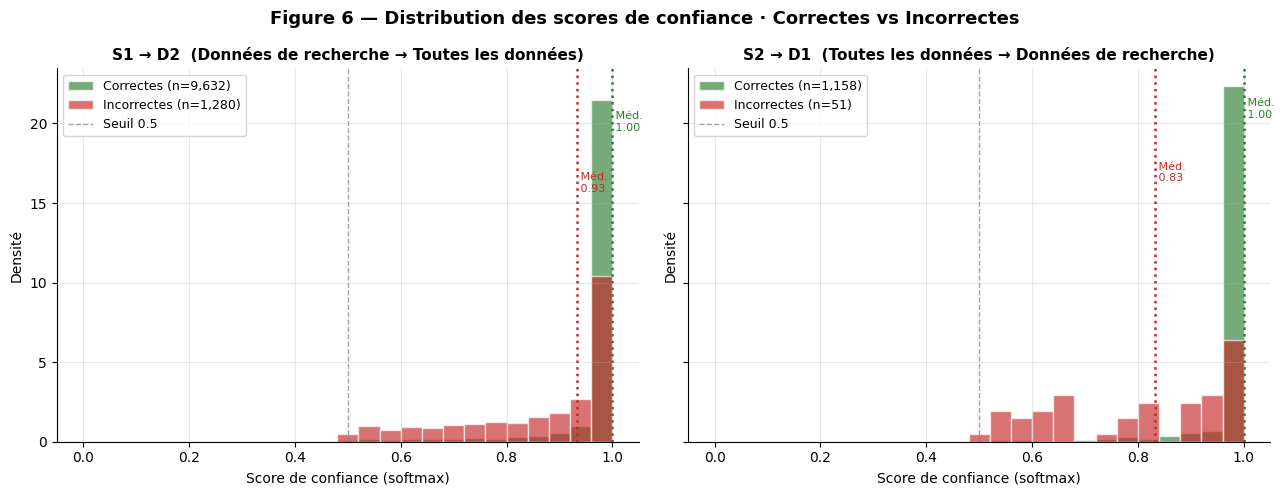

✓ Figure 6 sauvegardée


In [13]:
# ── Figure 6 : Distribution des scores de confiance ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, res in zip(axes, resultats):
    conf_ok  = res['conf_correct']
    conf_ko  = res['conf_incorrect']

    bins = np.linspace(0, 1, 26)
    ax.hist(conf_ok, bins=bins, alpha=0.65, color=PALETTE['correct'],
            label=f'Correctes (n={len(conf_ok):,})', density=True, edgecolor='white')
    ax.hist(conf_ko, bins=bins, alpha=0.65, color=PALETTE['error'],
            label=f'Incorrectes (n={len(conf_ko):,})', density=True, edgecolor='white')

    ax.axvline(0.5, color='grey', linestyle='--', linewidth=1.0,
               alpha=0.7, label='Seuil 0.5')

    # Statistiques
    med_ok = np.median(conf_ok) if conf_ok else 0
    med_ko = np.median(conf_ko) if conf_ko else 0
    ax.axvline(med_ok, color=PALETTE['correct'], linestyle=':', linewidth=1.8)
    ax.axvline(med_ko, color=PALETTE['error'],   linestyle=':', linewidth=1.8)
    ax.text(med_ok, ax.get_ylim()[1]*0.92 if ax.get_ylim()[1] > 0 else 1,
            f' Méd.\n {med_ok:.2f}', color=PALETTE['correct'], fontsize=8, va='top')
    if conf_ko:
        ax.text(med_ko, ax.get_ylim()[1]*0.75 if ax.get_ylim()[1] > 0 else 0.75,
                f' Méd.\n {med_ko:.2f}', color=PALETTE['error'], fontsize=8, va='top')

    ax.set_xlabel('Score de confiance (softmax)', fontsize=10)
    ax.set_ylabel('Densité', fontsize=10)
    ax.set_title(res['nom'], fontweight='bold', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Figure 6 — Distribution des scores de confiance · Correctes vs Incorrectes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'fig6_confiance_{RUN_TAG}.png'), dpi=150)
plt.show()
print('✓ Figure 6 sauvegardée')

## 📐 Comparaison delta — Écarts entre évaluations croisées

Ce tableau et ce graphique quantifient l'écart entre S1→D2 et S2→D1 pour chaque métrique. Une valeur positive indique que S2→D1 surpasse S1→D2. Cette comparaison directe répond à la question centrale : **quel modèle généralise le mieux vers un domaine non vu ?**

Δ = S2→D1 − S1→D2 (valeur positive : S2→D1 est meilleur)
───────────────────────────────────────────────────────
  Accuracy     : Δ = ++7.51 pp  → avantage : S2 → D1  (Toutes les données → Données de recherche)
  F1-Macro     : Δ = ++7.51 pp  → avantage : S2 → D1  (Toutes les données → Données de recherche)
  Précision    : Δ = ++7.63 pp  → avantage : S2 → D1  (Toutes les données → Données de recherche)
  Rappel       : Δ = ++7.51 pp  → avantage : S2 → D1  (Toutes les données → Données de recherche)
  Kappa        : Δ = ++15.02 pp  → avantage : S2 → D1  (Toutes les données → Données de recherche)


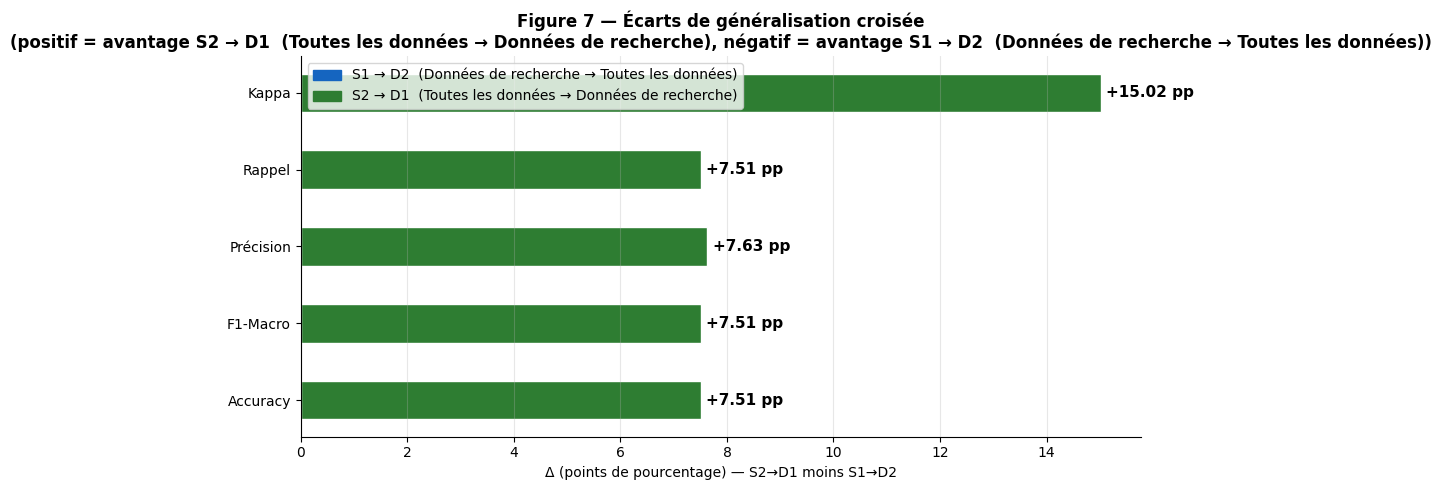

✓ Figure 7 sauvegardée


In [14]:
# ── Figure 7 : Graphique delta (écarts entre les deux évaluations) ──
metriques_delta = ['accuracy', 'f1_macro', 'precision', 'recall', 'kappa']
labels_delta    = ['Accuracy', 'F1-Macro', 'Précision', 'Rappel', 'Kappa']

r1, r2 = resultats[0], resultats[1]  # S1→D2, S2→D1
deltas = [(r2[m] - r1[m]) * 100 for m in metriques_delta]

print('Δ = S2→D1 − S1→D2 (valeur positive : S2→D1 est meilleur)')
print('─'*55)
for lbl, d in zip(labels_delta, deltas):
    signe = '+' if d >= 0 else ''
    favori = r2['nom'] if d > 0 else (r1['nom'] if d < 0 else 'Égalité')
    print(f'  {lbl:<12} : Δ = {signe}{d:+.2f} pp  → avantage : {favori}')

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = [PALETTE['S2→D1'] if d >= 0 else PALETTE['S1→D2'] for d in deltas]
bars = ax.barh(labels_delta, deltas, color=colors_bar, edgecolor='white', height=0.5)

for bar, d in zip(bars, deltas):
    ha  = 'left'  if d >= 0 else 'right'
    off = 0.1 if d >= 0 else -0.1
    ax.text(d + off, bar.get_y() + bar.get_height()/2,
            f'{d:+.2f} pp', va='center', ha=ha, fontweight='bold', fontsize=11)

ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel('Δ (points de pourcentage) — S2→D1 moins S1→D2', fontsize=10)
ax.set_title('Figure 7 — Écarts de généralisation croisée\n'
             f'(positif = avantage {r2["nom"]}, négatif = avantage {r1["nom"]})',
             fontsize=12, fontweight='bold')

patch1 = mpatches.Patch(color=PALETTE['S1→D2'], label=r1['nom'])
patch2 = mpatches.Patch(color=PALETTE['S2→D1'], label=r2['nom'])
ax.legend(handles=[patch1, patch2], fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'fig7_delta_{RUN_TAG}.png'), dpi=150)
plt.show()
print('✓ Figure 7 sauvegardée')

## 📝 Synthèse interprétative

Ce bloc produit un résumé automatique des résultats, conçu pour être copié directement dans la section de discussion de la thèse. Il interprète :
1. le modèle le plus robuste hors domaine,
2. l'asymétrie FN vs FP critique pour la surveillance phytosanitaire,
3. la calibration des scores de confiance (erreurs confiantes ou non).

In [15]:
# ── Synthèse textuelle automatique ──
r1, r2 = resultats[0], resultats[1]

# Meilleur modèle global
best = r1 if r1['f1_macro'] >= r2['f1_macro'] else r2
other = r2 if best is r1 else r1
delta_f1  = abs(best['f1_macro'] - other['f1_macro']) * 100
delta_acc = abs(best['accuracy'] - other['accuracy']) * 100

# FN pour chaque éval (index ambrosia)
def taux_fn(res):
    cm   = np.array(res['confusion'])
    ia   = res['idx_ambr']
    i_n  = 1 - ia
    tp   = cm[ia, ia]; fn = cm[ia, i_n]
    return fn / (tp + fn) * 100 if (tp + fn) > 0 else 0

def taux_fp(res):
    cm   = np.array(res['confusion'])
    ia   = res['idx_ambr']
    i_n  = 1 - ia
    tn   = cm[i_n, i_n]; fp = cm[i_n, ia]
    return fp / (tn + fp) * 100 if (tn + fp) > 0 else 0

med_ko_1 = np.median(r1['conf_incorrect']) if r1['conf_incorrect'] else 0
med_ko_2 = np.median(r2['conf_incorrect']) if r2['conf_incorrect'] else 0

print('══════════════════════════════════════════════════════════════')
print('  SYNTHÈSE INTERPRÉTATIVE — CROSS-ÉVALUATION S1 ↔ S2')
print('══════════════════════════════════════════════════════════════')
print(f"""
L'évaluation croisée révèle que {best['nom']} obtient la meilleure
généralisation hors domaine avec un F1-Macro de {best['f1_macro']:.4f}
(Accuracy {best['accuracy']*100:.2f} %  IC Wilson 95 % {best['wilson_acc'][0]*100:.2f}–{best['wilson_acc'][1]*100:.2f} %)
contre {other['f1_macro']:.4f} pour {other['nom']}
(Δ F1 = {delta_f1:+.2f} pp, Δ Accuracy = {delta_acc:+.2f} pp).

PROFIL D'ERREUR (perspective surveillance phytosanitaire) :
  {r1['nom']}
    Faux Négatifs (ambrosia manqué) : {taux_fn(r1):.2f} %
    Faux Positifs (fausse alarme)   : {taux_fp(r1):.2f} %
  {r2['nom']}
    Faux Négatifs (ambrosia manqué) : {taux_fn(r2):.2f} %
    Faux Positifs (fausse alarme)   : {taux_fp(r2):.2f} %

CALIBRATION DES ERREURS :
  Score médian des prédictions incorrectes :
    {r1['nom']} → {med_ko_1:.3f}  {'(erreurs confiantes — seuil > 0.7)' if med_ko_1 > 0.7 else '(erreurs peu confiantes)'}
    {r2['nom']} → {med_ko_2:.3f}  {'(erreurs confiantes — seuil > 0.7)' if med_ko_2 > 0.7 else '(erreurs peu confiantes)'}

KAPPA DE COHEN :
  {r1['nom']} : {r1['kappa']:.4f}  {'(excellent > 0.80)' if r1['kappa'] > 0.80 else '(bon > 0.60)' if r1['kappa'] > 0.60 else '(modéré)'}
  {r2['nom']} : {r2['kappa']:.4f}  {'(excellent > 0.80)' if r2['kappa'] > 0.80 else '(bon > 0.60)' if r2['kappa'] > 0.60 else '(modéré)'}
""")
print('══════════════════════════════════════════════════════════════')

══════════════════════════════════════════════════════════════
  SYNTHÈSE INTERPRÉTATIVE — CROSS-ÉVALUATION S1 ↔ S2
══════════════════════════════════════════════════════════════

L'évaluation croisée révèle que S2 → D1  (Toutes les données → Données de recherche) obtient la meilleure
généralisation hors domaine avec un F1-Macro de 0.9578
(Accuracy 95.78 %  IC Wilson 95 % 94.50–96.78 %)
contre 0.8827 pour S1 → D2  (Données de recherche → Toutes les données)
(Δ F1 = +7.51 pp, Δ Accuracy = +7.51 pp).

PROFIL D'ERREUR (perspective surveillance phytosanitaire) :
  S1 → D2  (Données de recherche → Toutes les données)
    Faux Négatifs (ambrosia manqué) : 12.01 %
    Faux Positifs (fausse alarme)   : 11.45 %
  S2 → D1  (Toutes les données → Données de recherche)
    Faux Négatifs (ambrosia manqué) : 1.65 %
    Faux Positifs (fausse alarme)   : 6.79 %

CALIBRATION DES ERREURS :
  Score médian des prédictions incorrectes :
    S1 → D2  (Données de recherche → Toutes les données) → 0.933  (erre

## 💾 Sauvegarde JSON

In [16]:
resume = {
    'run_tag'   : RUN_TAG,
    'img_size'  : IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'modeles'   : {'S1': S1_MODEL, 'S2': S2_MODEL},
    'donnees'   : {
        'D1_pos': D1_POS, 'D1_neg': D1_NEG,
        'D2_pos': D2_POS, 'D2_neg': D2_NEG,
    },
    'resultats' : {'M1_D2': res_M1_D2, 'M2_D1': res_M2_D1},
}

out_json = os.path.join(OUT_DIR, f'cross_eval_{RUN_TAG}.json')
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(resume, f, indent=2, ensure_ascii=False)
print(f'✓ Résumé JSON : {out_json}')


✓ Résumé JSON : /content/drive/MyDrive/Cross_Evaluation_S1_S2/cross_eval_20260619_235133.json


## ✅ Vérification de la sauvegarde sur Drive

Bloc ajouté pour diagnostiquer les problèmes de sauvegarde : liste le contenu réel du dossier de sortie, affiche la taille de chaque fichier, et force le flush du cache Drive pour que les fichiers apparaissent immédiatement dans l'interface web.


In [17]:
# Vérification : lister tout ce qui a été réellement écrit dans OUT_DIR
import os, time

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Contenu du dossier de sortie')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  {OUT_DIR}')
print()

if not os.path.exists(OUT_DIR):
    print('  ✗ Le dossier n\'existe pas !')
else:
    fichiers = sorted(os.listdir(OUT_DIR))
    if not fichiers:
        print('  ✗ Dossier vide')
    else:
        total_ko = 0
        for f in fichiers:
            chemin = os.path.join(OUT_DIR, f)
            taille = os.path.getsize(chemin)
            total_ko += taille / 1024
            mtime = time.strftime('%H:%M:%S', time.localtime(os.path.getmtime(chemin)))
            print(f'  ✓ {f:<50} {taille/1024:>8.1f} KB  (écrit à {mtime})')
        print(f'\n  Total : {len(fichiers)} fichier(s) — {total_ko:.1f} KB')

# Force la synchronisation Drive pour que les fichiers apparaissent dans l\'interface web
print('\n  Flush Drive en cours...')
try:
    from google.colab import drive
    drive.flush_and_unmount()
    time.sleep(2)
    drive.mount('/content/drive', force_remount=False)
    print('  ✓ Drive synchronisé — les fichiers devraient maintenant être visibles.')
    print(f'\n  Ouvre manuellement : https://drive.google.com/drive/my-drive')
    print(f'  puis cherche le dossier : {os.path.basename(OUT_DIR)}')
except Exception as e:
    print(f'  ⚠ Flush échoué : {e}')
    print('  Les fichiers sont écrits mais peuvent prendre quelques minutes à apparaître.')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Contenu du dossier de sortie
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  /content/drive/MyDrive/Cross_Evaluation_S1_S2

  ✓ cross_eval_20260619_235133.json                      1296.1 KB  (écrit à 02:05:30)
  ✓ fig1_barres_20260619_235133.png                        87.9 KB  (écrit à 01:57:57)
  ✓ fig2_confusion_20260619_235133.png                    117.5 KB  (écrit à 01:58:11)
  ✓ fig3_distribution_20260619_235133.png                  70.1 KB  (écrit à 01:58:30)
  ✓ fig4_radar_20260619_235133.png                        211.4 KB  (écrit à 01:58:42)
  ✓ fig5_erreurs_20260619_235133.png                       99.2 KB  (écrit à 01:58:51)
  ✓ fig6_confiance_20260619_235133.png                     87.8 KB  (écrit à 01:59:03)
  ✓ fig7_delta_20260619_235133.png                         85.2 KB  (écrit à 01:59:10)
  ✓ metriques_par_classe_20260619_235133.csv                0.5 KB  (écrit à 01:45:29)
  ✓ resume_cross_eval_20260619_235133.c